<a href="https://colab.research.google.com/github/Shashi-kumar-g/machine-learning-26/blob/main/Copy_of_PCA_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Original dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of classes:", len(target_names))


Original dataset shape: (150, 4)
Number of features: 4
Number of classes: 3


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nAfter standardization:")
print("Mean of features:", X_scaled.mean(axis=0))
print("Standard deviation:", X_scaled.std(axis=0))


After standardization:
Mean of features: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Standard deviation: [1. 1. 1. 1.]


In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA transformed shape:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca.explained_variance_ratio_.sum())


PCA transformed shape: (150, 2)

Explained variance ratio:
[0.72962445 0.22850762]

Total variance retained: 0.9581320720000166


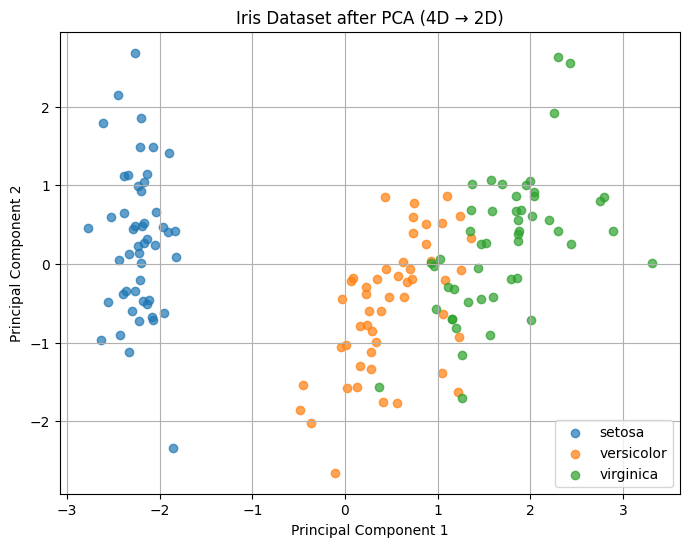

In [5]:
#Principal component plotings
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(target_names):

    plt.scatter(
        X_pca[y == class_id, 0],
        X_pca[y == class_id, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset after PCA (4D → 2D)")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#Principal component based variance
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("\nExplained variance of all principal components:")

for i, variance in enumerate(explained_variance):
    print(
        f"PC{i+1}: {variance:.4f} "
        f"({variance*100:.2f}%)"
    )


Explained variance of all principal components:
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)
PC3: 0.0367 (3.67%)
PC4: 0.0052 (0.52%)


In [7]:
# Same train-test split for fair comparison

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42

)

In [8]:
# Logistic Regression using ORIGINAL 4 features


model_original = LogisticRegression(max_iter=1000)

model_original.fit(X_train, y_train)

y_pred_original = model_original.predict(X_test)

accuracy_original = accuracy_score(
    y_test,
    y_pred_original
)

In [9]:
#After PCA
pca_2 = PCA(n_components=2)

X_train_pca = pca_2.fit_transform(X_train)
X_test_pca = pca_2.transform(X_test)

In [10]:
# Logistic Regression using ONLY 2 PCA features

model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)


In [11]:

print("PCA EFFECTIVENESS")


print(
    f"Original features: 4"
)

print(
    f"PCA features:      2"
)

print(
    f"\nAccuracy using original 4 features: "
    f"{accuracy_original:.4f}"
)

print(
    f"Accuracy using 2 PCA features:      "
    f"{accuracy_pca:.4f}"
)

print(
    f"\nVariance retained by 2 PCs: "
    f"{pca_2.explained_variance_ratio_.sum()*100:.2f}%"
)

PCA EFFECTIVENESS
Original features: 4
PCA features:      2

Accuracy using original 4 features: 1.0000
Accuracy using 2 PCA features:      0.9000

Variance retained by 2 PCs: 95.62%
